<a href="https://colab.research.google.com/github/nalinkai/Data-Science-Project-Lifecycle/blob/Dev/Kernel_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Hotel Booking Cancellation Prediction - Kernel SVM Model

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd
# Load the finalized dataset after preprocessing and feature engineering
df = pd.read_csv('/content/drive/MyDrive/IIT/3rd Year/2nd Sem/DSPL/GCW/Model/Hotel-A-train_finalized.csv')

# View first few rows
df.head()

,Reservation-id,Age,Income,Adults,Children,Babies,Visted_Previously,Previous_Cancellations,Reservation_Status,Discount_Rate,...,Educational_Level_high-school,Educational_Level_mid-school,Meal_Type_fb,Meal_Type_hb,Deposit_type_non-refundable,Deposit_type_refundable,Booking_channel_direct,Booking_channel_online,Required_Car_Parking_yes,Use_Promotion_yes
0,39428300,40.0,0.000000,2.0,2.0,0.0,0,0,check-out,0.250,...,False,False,False,False,False,False,False,True,True,True
1,77491756,49.0,0.666667,3.0,3.0,0.0,0,0,check-out,0.000,...,False,True,False,False,False,True,False,True,True,False
2,73747291,42.0,0.000000,3.0,3.0,0.0,0,0,check-out,0.000,...,False,False,False,False,False,False,False,True,True,False
3,67301739,25.0,1.000000,4.0,3.0,0.0,0,0,check-out,0.125,...,False,False,False,False,False,True,False,False,True,True
4,77222321,62.0,0.333333,1.0,1.0,0.0,0,0,check-out,0.250,...,True,False,False,False,False,False,True,False,False,True


In [ ]:
# Separate features (X) and target variable (y)
X = df.drop(columns=['Reservation_Status'])
y = df['Reservation_Status']

In [ ]:
# Convert categorical variables into numerical format using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets (80% train, 20% test)
# Stratify is used to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from sklearn.preprocessing import StandardScaler

# SVM is sensitive to feature scale, so we standardize the data
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.svm import SVC

# Using RBF kernel to capture non-linear patterns
model_svm = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)

# Train the model
model_svm.fit(X_train, y_train)

SVC(C=1, random_state=42)

In [ ]:
# Predict reservation status
y_pred = model_svm.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Check model accuracy
print("Test Accuracy:", accuracy_score(y_test, y_pred))

# Detailed evaluation
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Test Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

    canceled       1.00      1.00      1.00       822
   check-out       1.00      1.00      1.00      4155
     no-show       1.00      1.00      1.00       421

    accuracy                           1.00      5398
   macro avg       1.00      1.00      1.00      5398
weighted avg       1.00      1.00      1.00      5398



In [ ]:
# Check for overfitting
train_pred = model_svm.predict(X_train)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Train Accuracy: 1.0
Test Accuracy: 1.0


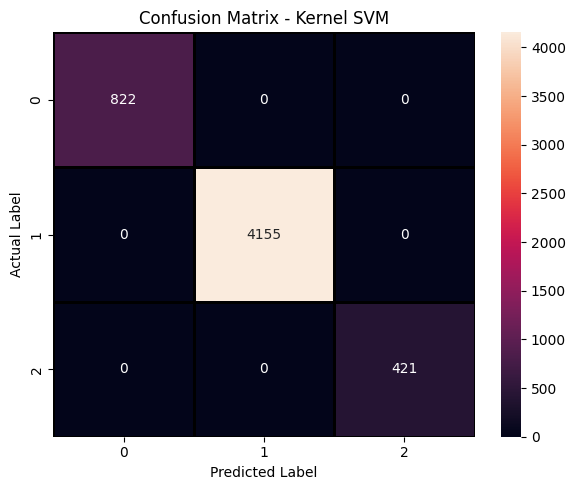

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    linewidths=1,
    linecolor='black'
)

plt.title("Confusion Matrix - Kernel SVM")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()